# CN1 - LE PENDULE DE FOUCAULT


Objectif : *« À l’aide d’un langage de programmation, illustrer un effet lié au
caractère non galiléen du référentiel terrestre. »*

Cette capacité numérique est associée à l'exercice du TD 2 : *Le pendule de Foucault*.

### A) Préliminaire 
L'expérience du pendule de Foucault a permis de mettre en évidence la rotation de la Terre sur elle-même. On considère un pendule simple, constitué d'un fil de longueur $L$ au bout duquel on place une masse ponctuelle $m$, dont le point d'accroche en $A$ est fixe dans le référentiel terrestre. 
Comme l'amplitude des oscillations et faible, on supposera pour simplifier que le pendule oscille dans le plan horizontal ($\vec{e_x},\vec{e_y}$) où l'on a choisi $\vec{e_x}$ qui pointe vers l'est, et $\vec{e_y}$ vers le nord.  L'axe $\vec{e_z}$ pointe vers la verticale ascendante. On néglige tout frottement. On lance le pendule, initialement à la verticale, avec une vitesse initiale $v_0$ suivant l'axe $(Ox)$. On rappelle que la loi horaire du mouvement du pendule est donnée par 
$$
\begin{cases}
x(t) & =  +x_0 \cos(\Omega \sin\lambda~t)\sin(\omega t),\\
y(t) & = -x_0 \sin(\Omega \sin\lambda~t)\sin(\omega t),
\end{cases}
$$
où $x_0 = \frac{v_0}{\omega}$ est l'amplitude du mouvement, $\lambda$ la latitude, et $\omega=\sqrt{\Omega^2\sin^2\lambda + \omega_0^2}$ la pulsation des oscillations du pendule avec $\omega_0 = \sqrt{\frac{g}{L}}$ la pulsation propre du pendule.

### B) Étude graphique
> **Question 1**
> 
> Le pendule de Foucault présent au Panthéon à Paris, de latitude $\lambda=45$ °, a pour longueur $L=63$ m. Déterminer numériquement la pulsation propre $\omega_0$ et la vitesse angulaire de rotation du plan d'oscillation $\Omega \sin \lambda$. Déterminer de même les périodes associées $T_0$ et $T$. Les comparer.

In [5]:
import numpy as np

""" PARAMÈTRES PHYSIQUES """
g     = 9.81            # accélération de la pesanteur (en m.s^-2)
Tsid  = 86000           # jour sidéral (en s)
Omega = 2*np.pi/Tsid    # vitesse angulaire de la Terre (en rad.s^-1)
lat   = 45              # latitude (en degré)
L     = 63              # longueur du pendule (en m)

omega0   = np.sqrt(g/L)                      # pulsation propre du pendule
T0       = 2*np.pi/omega0                    # période propre du pendule

> **Question 2**
> 
> Que devrait valoir la période du jour sidéral $T_{\rm sid}$ pour que le plan d'oscillation du pendule fasse un tour complet au bout de $20$ oscillations ? Attribuer cette valeur numérique à la variable `Tsid` et définir les grandeurs ci-dessous. On utilisera cette valeur pour la suite.

In [6]:
Tsid     = 200                               # jour sidéral (en s)
Omega    = 2*np.pi/Tsid                      # vitesse angulaire de la Terre (en rad.s^-1)
Omegaloc = Omega*np.sin(lat/180*np.pi)       # pulsation plan oscillation (en rad.s^-1)
T        = 2*np.pi/Omegaloc                  # période plan oscillation (en s)
omega    = np.sqrt(omega0**2 + Omegaloc**2)  # pulsation du pendule (en rad.s^-1)

> **Question 3**
> 
> On souhaite tracer la trajectoire du pendule sur une durée équivalente à $N=10$ périodes propres du pendule. Définir un tableau `numpy` contenant $1000$ valeurs de temps échantillonnées dans cet intervalle. On utilisera la fonction `np.linspace`. Définir le tableau des positions $x$ et $y$ correspondant à ces instants pour une vitesse initiale $v_0=1~\rm{m}\cdot\rm{s}^{-1}$.

In [7]:
t    = np.linspace(0,10*T0,1000)            # tableau des instants de tracé
v0 = 1                                      # vitesse initiale    
x0 = v0/omega                               # amplitude du mouvement
x = +x0*np.cos(Omegaloc*t)*np.sin(omega*t)  # position x du pendule
y = -x0*np.sin(Omegaloc*t)*np.sin(omega*t)  # position y du pendule

> **Question 4**
> 
> Compléter puis exécuter le code suivant de façon à produire un graphe de la trajectoire du pendule dans le plan horizontal. Observer commenter. Relancer le code en faisant varier les paramètres vitesse initiale $v_0$, latitude $\lambda$, etc.

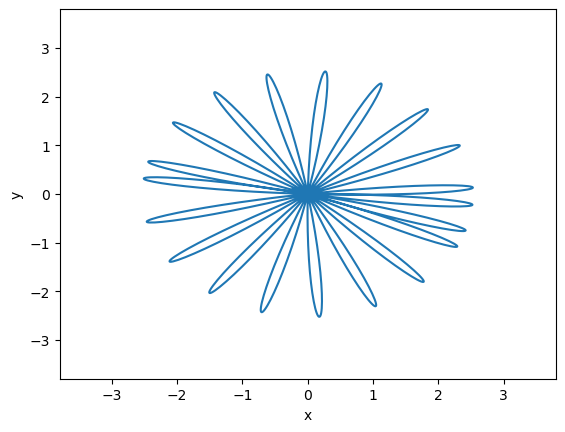

In [8]:
""" TRACÉ """
import matplotlib.pyplot as plt
plt.figure()
plt.xlim(-1.5*x0,1.5*x0)
plt.ylim(-1.5*x0,1.5*x0)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x,y)
plt.show()